In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pickle
import sys
import optuna
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from utils import preprocess_catboost, get_model_metrics, get_model_figs
import numpy as np
from matplotlib.colors import Normalize
from sklearn.metrics import root_mean_squared_error

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from atow_estimation.paths import PROCESSED_DATA_DIR

c:\Users\jaguevara\AppData\Local\anaconda3\envs\TFM\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data_m1 = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_m1.csv"))
data_m2 = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_m2.csv"))
data_H = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_H.csv"))
data_M = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_M.csv"))
data_m1_M = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_m1_M.csv"))
data_m1_H = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_m1_H.csv"))
data_m2_M = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_m2_M.csv"))
data_m2_H = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_m2_H.csv"))

### Model 1 Medium Wake

In [5]:
X_train, X_test, y_train, y_test, train_pool, test_pool = preprocess_catboost(data_m1_M)

In [6]:
def objective(trial):
    params = {
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1.0, 50.0), 
        'depth': trial.suggest_int('depth', 4, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 30),
        'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations', 1, 15),
    }

    fixed_params = {
        'iterations': 2000, # Max iterations, early stopping will determine actual
        'learning_rate': 0.05, # Fixed learning rate as per original snippet
        'eval_metric': 'RMSE', # Standard string for RMSE
        'random_seed': 42,
        'verbose': False,
        # 'objective': 'RMSE', # In CatBoost, 'loss_function' is preferred, or inferred for Regressor
        'loss_function': 'RMSE',
        'task_type': 'CPU',
        'use_best_model': True, # Crucial for early stopping
        'od_type': 'Iter',      # Early stopping type
        'od_wait': 50,          # Early stopping wait iterations
        'allow_writing_files': False,
    }

    model = CatBoostRegressor(
        **fixed_params,
        **params # Tuned parameters are passed here
    )

    model.fit(train_pool, eval_set=test_pool) 

    best_rmse_on_val = model.get_best_score()['validation']['RMSE'] # Correct for CatBoost
    
    # Store the number of iterations for the best model in this trial
    trial.set_user_attr("best_iteration_count", model.get_best_iteration())
    
    return best_rmse_on_val

In [7]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

print("\n--- Optuna Study Results ---")
print(f"Number of finished trials: {len(study.trials)}")
best_trial = study.best_trial
print(f"Best trial RMSE: {best_trial.value}")
print(f"Best trial params: {best_trial.params}")
optimal_iterations = best_trial.user_attrs.get("best_iteration_count")
print(f"Best trial optimal iterations: {optimal_iterations}")

[I 2025-05-25 19:35:00,890] A new study created in memory with name: no-name-053d84aa-f3ed-4399-8e7c-112ea779c0df
[I 2025-05-25 19:43:07,267] Trial 0 finished with value: 1418.2997637489161 and parameters: {'reg_lambda': 1.4171056598806127, 'random_strength': 3.681674572145546, 'depth': 10, 'min_data_in_leaf': 16, 'leaf_estimation_iterations': 2}. Best is trial 0 with value: 1418.2997637489161.
[I 2025-05-25 19:44:40,887] Trial 1 finished with value: 1353.73619601208 and parameters: {'reg_lambda': 0.0845906212269345, 'random_strength': 36.48813428446936, 'depth': 5, 'min_data_in_leaf': 5, 'leaf_estimation_iterations': 4}. Best is trial 1 with value: 1353.73619601208.
[I 2025-05-25 19:46:28,628] Trial 2 finished with value: 1363.1895925132842 and parameters: {'reg_lambda': 0.35570709079349433, 'random_strength': 5.918788971034248, 'depth': 5, 'min_data_in_leaf': 9, 'leaf_estimation_iterations': 9}. Best is trial 1 with value: 1353.73619601208.
[I 2025-05-25 19:50:04,795] Trial 3 finishe


--- Optuna Study Results ---
Number of finished trials: 10
Best trial RMSE: 1337.8773420766383
Best trial params: {'reg_lambda': 0.062389982306315865, 'random_strength': 40.655597356417914, 'depth': 5, 'min_data_in_leaf': 5, 'leaf_estimation_iterations': 3}
Best trial optimal iterations: 1992


In [8]:
best_hyperparams = best_trial.params.copy()

final_model_params = {
    'iterations': optimal_iterations, # Use the determined optimal number of iterations
    'learning_rate': 0.05,          # As per original fixed param
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'verbose': False,               # Or True if you want to see training output for the final model
    'loss_function': 'RMSE',
    'task_type': 'CPU',
    'allow_writing_files': False,
}
final_model_params.update(best_hyperparams) # Add/overwrite with tuned hyperparams

final_model = CatBoostRegressor(**final_model_params)
final_model.fit(train_pool)

In [9]:
y_pred = final_model.predict(X_test)
r2, mae, rmse, mape =  get_model_metrics(y_pred, X_test, y_test)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error: 962.37
Root Mean Squared Error: 1337.88
R^2 Score: 0.9670


In [10]:
with open('../models/CatBoost_m1_M.pkl', 'wb') as file:  
    pickle.dump(final_model, file)

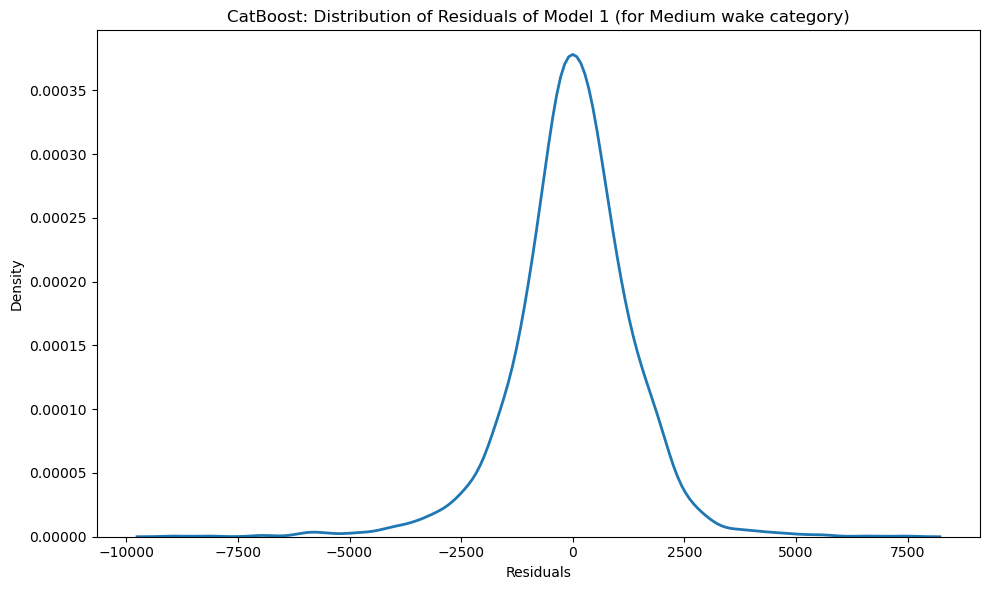

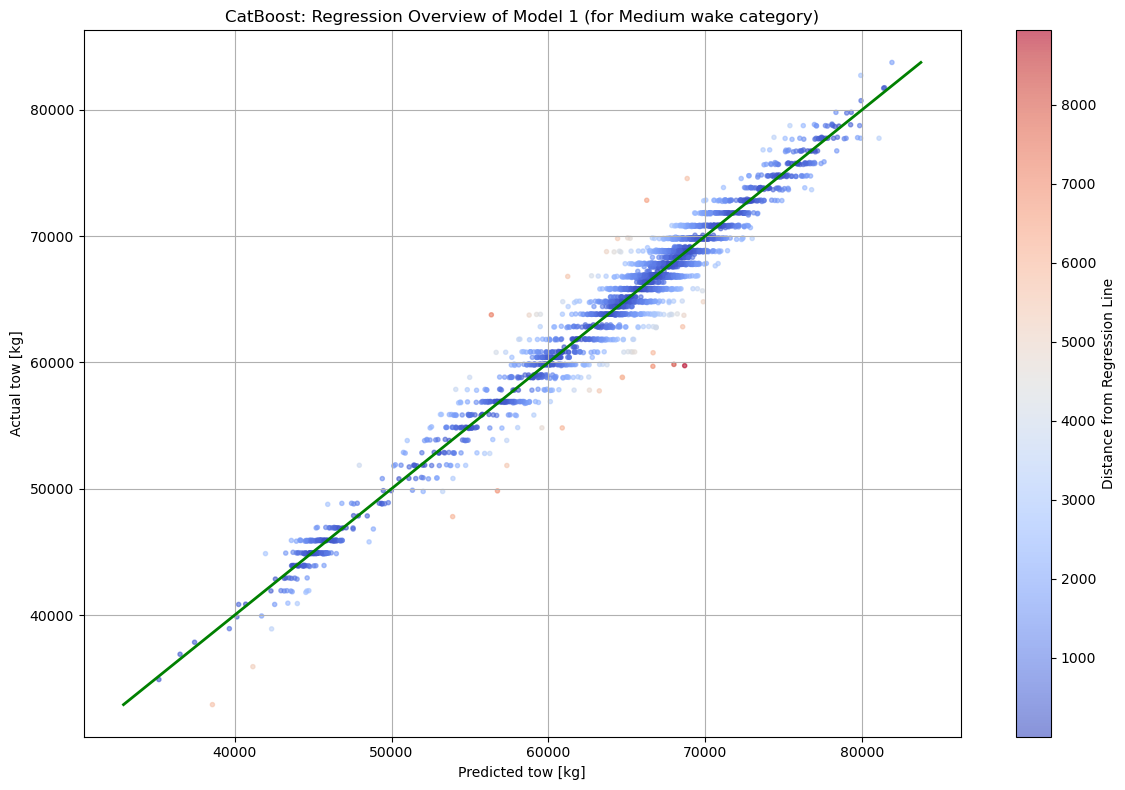

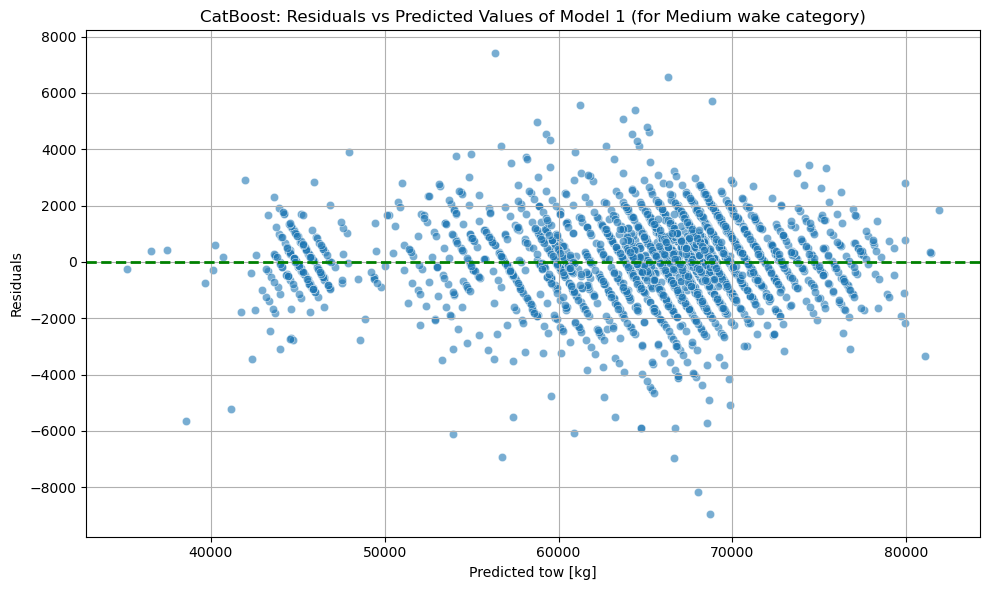

In [11]:
residuals = y_test - y_pred

title1 = "CatBoost: Distribution of Residuals of Model 1 (for Medium wake category)"
title2 = "CatBoost: Regression Overview of Model 1 (for Medium wake category)"
title3 = "CatBoost: Residuals vs Predicted Values of Model 1 (for Medium wake category)"

path1 = "../reports/figures/m1/M_wake/catboost_residuals_distribution.png"
path2 = "../reports/figures/m1/M_wake/catboost_scatter.png"
path3 = "../reports/figures/m1/M_wake/catboost_scatter_residuals.png"

get_model_figs(residuals, y_pred, y_test, title1, title2, title3, path1, path2, path3)

### Model 1 Heavy Wake

In [12]:
X_train, X_test, y_train, y_test, train_pool, test_pool = preprocess_catboost(data_m1_H)

In [13]:
def objective(trial):
    params = {
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1.0, 50.0), 
        'depth': trial.suggest_int('depth', 4, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 30),
        'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations', 1, 15),
    }

    fixed_params = {
        'iterations': 2000, # Max iterations, early stopping will determine actual
        'learning_rate': 0.05, # Fixed learning rate as per original snippet
        'eval_metric': 'RMSE', # Standard string for RMSE
        'random_seed': 42,
        'verbose': False,
        # 'objective': 'RMSE', # In CatBoost, 'loss_function' is preferred, or inferred for Regressor
        'loss_function': 'RMSE',
        'task_type': 'CPU',
        'use_best_model': True, # Crucial for early stopping
        'od_type': 'Iter',      # Early stopping type
        'od_wait': 50,          # Early stopping wait iterations
        'allow_writing_files': False,
    }

    model = CatBoostRegressor(
        **fixed_params,
        **params # Tuned parameters are passed here
    )

    model.fit(train_pool, eval_set=test_pool) 

    best_rmse_on_val = model.get_best_score()['validation']['RMSE'] # Correct for CatBoost
    
    # Store the number of iterations for the best model in this trial
    trial.set_user_attr("best_iteration_count", model.get_best_iteration())
    
    return best_rmse_on_val

In [14]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

print("\n--- Optuna Study Results ---")
print(f"Number of finished trials: {len(study.trials)}")
best_trial = study.best_trial
print(f"Best trial RMSE: {best_trial.value}")
print(f"Best trial params: {best_trial.params}")
optimal_iterations = best_trial.user_attrs.get("best_iteration_count")
print(f"Best trial optimal iterations: {optimal_iterations}")

[I 2025-05-25 20:30:19,012] A new study created in memory with name: no-name-6767c94a-5017-4104-8750-46b78288a873
[I 2025-05-25 20:30:47,610] Trial 0 finished with value: 5773.084997821477 and parameters: {'reg_lambda': 2.3788251378588154, 'random_strength': 4.158415157364526, 'depth': 5, 'min_data_in_leaf': 23, 'leaf_estimation_iterations': 9}. Best is trial 0 with value: 5773.084997821477.
[I 2025-05-25 20:31:47,831] Trial 1 finished with value: 6894.091256768337 and parameters: {'reg_lambda': 0.01325663635388702, 'random_strength': 2.0165542913351424, 'depth': 9, 'min_data_in_leaf': 21, 'leaf_estimation_iterations': 1}. Best is trial 0 with value: 5773.084997821477.
[I 2025-05-25 20:32:20,839] Trial 2 finished with value: 5750.252190690552 and parameters: {'reg_lambda': 0.02339150302279312, 'random_strength': 26.777448135933167, 'depth': 5, 'min_data_in_leaf': 17, 'leaf_estimation_iterations': 10}. Best is trial 2 with value: 5750.252190690552.
[I 2025-05-25 20:32:49,711] Trial 3 fi


--- Optuna Study Results ---
Number of finished trials: 10
Best trial RMSE: 5750.252190690552
Best trial params: {'reg_lambda': 0.02339150302279312, 'random_strength': 26.777448135933167, 'depth': 5, 'min_data_in_leaf': 17, 'leaf_estimation_iterations': 10}
Best trial optimal iterations: 893


In [15]:
best_hyperparams = best_trial.params.copy()

final_model_params = {
    'iterations': optimal_iterations, # Use the determined optimal number of iterations
    'learning_rate': 0.05,          # As per original fixed param
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'verbose': False,               # Or True if you want to see training output for the final model
    'loss_function': 'RMSE',
    'task_type': 'CPU',
    'allow_writing_files': False,
}
final_model_params.update(best_hyperparams) # Add/overwrite with tuned hyperparams

final_model = CatBoostRegressor(**final_model_params)
final_model.fit(train_pool)

In [16]:
y_pred = final_model.predict(X_test)
r2, mae, rmse, mape =  get_model_metrics(y_pred, X_test, y_test)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error: 4051.38
Root Mean Squared Error: 5750.99
R^2 Score: 0.9206


In [17]:
with open('../models/CatBoost_m1_H.pkl', 'wb') as file:  
    pickle.dump(final_model, file)

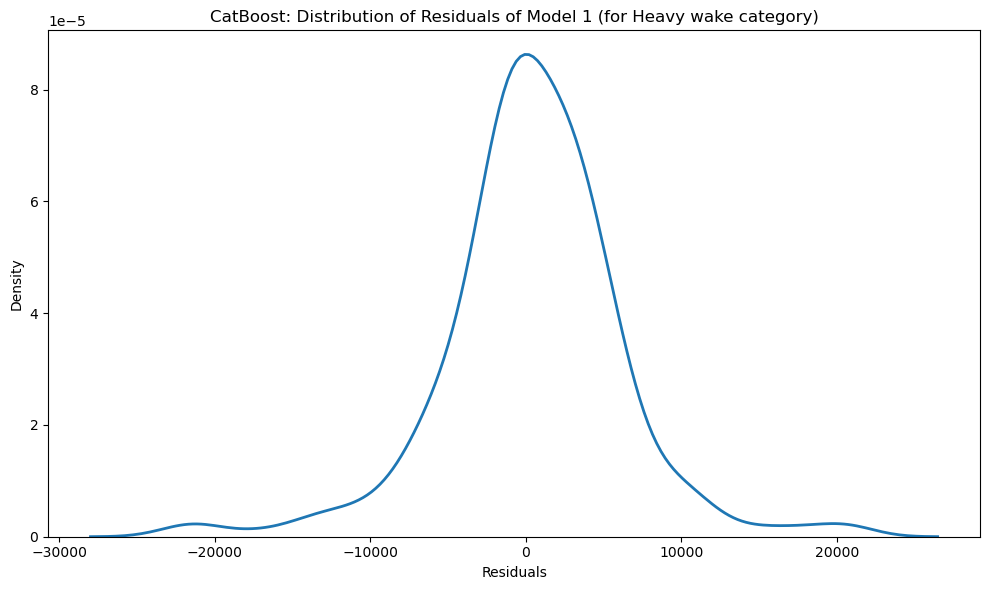

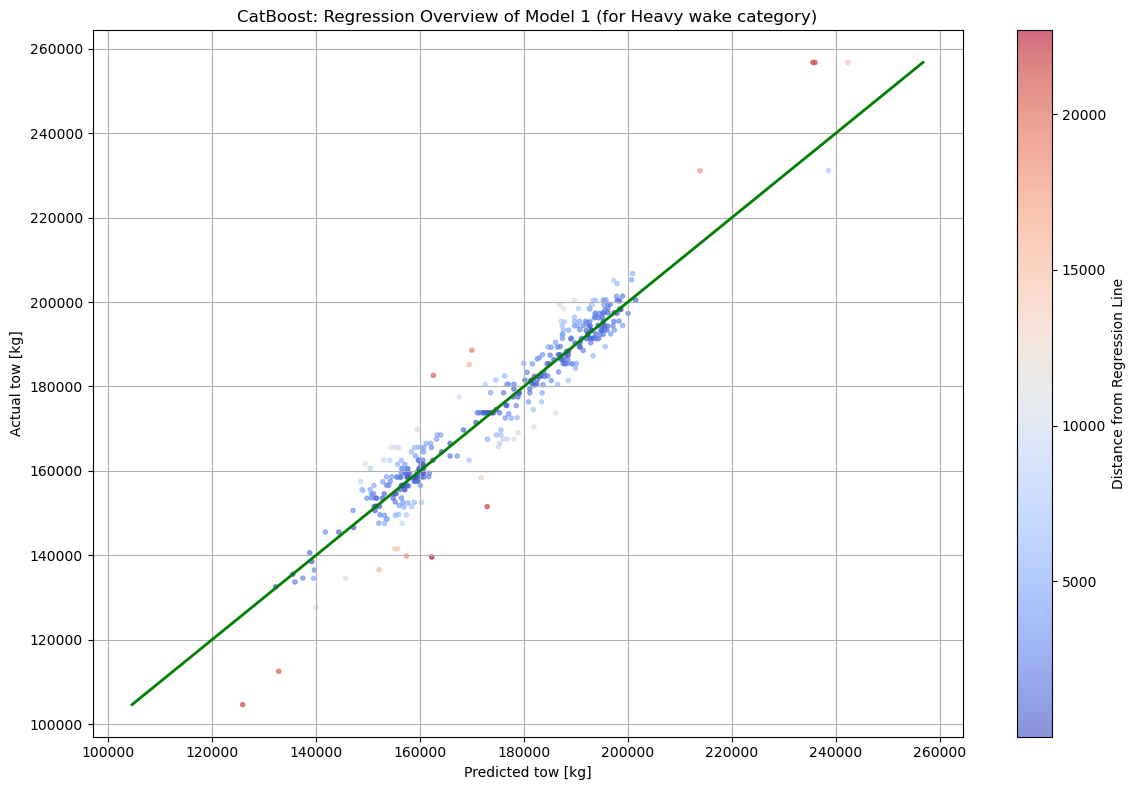

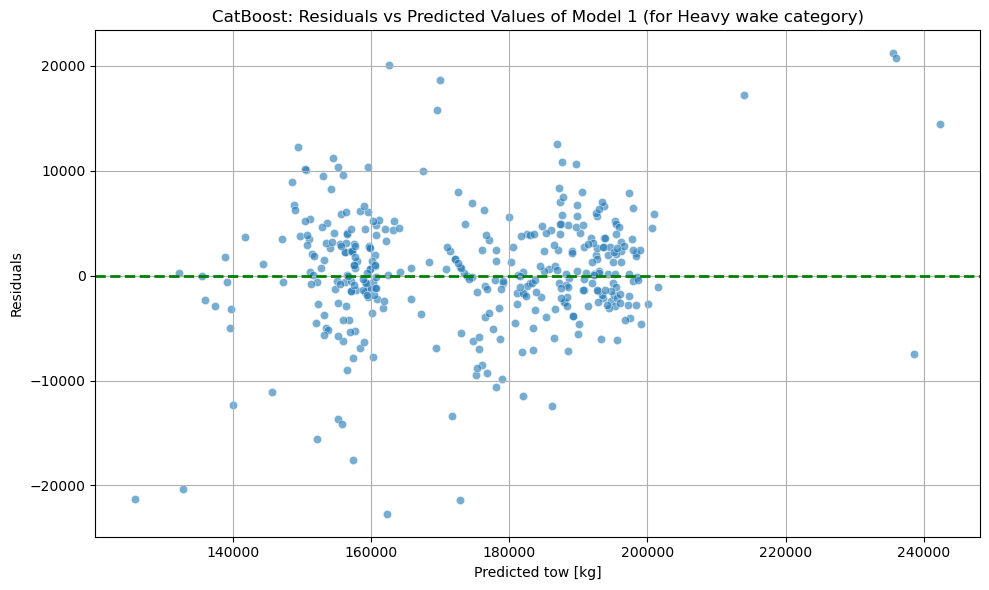

In [18]:
residuals = y_test - y_pred

title1 = "CatBoost: Distribution of Residuals of Model 1 (for Heavy wake category)"
title2 = "CatBoost: Regression Overview of Model 1 (for Heavy wake category)"
title3 = "CatBoost: Residuals vs Predicted Values of Model 1 (for Heavy wake category)"

path1 = "../reports/figures/m1/H_wake/catboost_residuals_distribution.png"
path2 = "../reports/figures/m1/H_wake/catboost_scatter.png"
path3 = "../reports/figures/m1/H_wake/catboost_scatter_residuals.png"

get_model_figs(residuals, y_pred, y_test, title1, title2, title3, path1, path2, path3)

### Model 2 Medium Wake

In [19]:
X_train, X_test, y_train, y_test, train_pool, test_pool = preprocess_catboost(data_m2_M)

In [20]:
def objective(trial):
    params = {
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1.0, 50.0), 
        'depth': trial.suggest_int('depth', 4, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 30),
        'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations', 1, 15),
    }

    fixed_params = {
        'iterations': 2000, # Max iterations, early stopping will determine actual
        'learning_rate': 0.05, # Fixed learning rate as per original snippet
        'eval_metric': 'RMSE', # Standard string for RMSE
        'random_seed': 42,
        'verbose': False,
        # 'objective': 'RMSE', # In CatBoost, 'loss_function' is preferred, or inferred for Regressor
        'loss_function': 'RMSE',
        'task_type': 'CPU',
        'use_best_model': True, # Crucial for early stopping
        'od_type': 'Iter',      # Early stopping type
        'od_wait': 50,          # Early stopping wait iterations
        'allow_writing_files': False,
    }

    model = CatBoostRegressor(
        **fixed_params,
        **params # Tuned parameters are passed here
    )

    model.fit(train_pool, eval_set=test_pool) 

    best_rmse_on_val = model.get_best_score()['validation']['RMSE'] # Correct for CatBoost
    
    # Store the number of iterations for the best model in this trial
    trial.set_user_attr("best_iteration_count", model.get_best_iteration())
    
    return best_rmse_on_val

In [21]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

print("\n--- Optuna Study Results ---")
print(f"Number of finished trials: {len(study.trials)}")
best_trial = study.best_trial
print(f"Best trial RMSE: {best_trial.value}")
print(f"Best trial params: {best_trial.params}")
optimal_iterations = best_trial.user_attrs.get("best_iteration_count")
print(f"Best trial optimal iterations: {optimal_iterations}")

[I 2025-05-25 20:42:09,159] A new study created in memory with name: no-name-0982cf9e-2617-4587-bd46-b17387a14864
[I 2025-05-25 20:47:31,763] Trial 0 finished with value: 1743.4561993085936 and parameters: {'reg_lambda': 2.118052510588696, 'random_strength': 49.803707366570016, 'depth': 10, 'min_data_in_leaf': 11, 'leaf_estimation_iterations': 10}. Best is trial 0 with value: 1743.4561993085936.
[I 2025-05-25 20:49:35,927] Trial 1 finished with value: 1728.0261364946891 and parameters: {'reg_lambda': 0.17620861336671484, 'random_strength': 37.710943564993265, 'depth': 6, 'min_data_in_leaf': 23, 'leaf_estimation_iterations': 5}. Best is trial 1 with value: 1728.0261364946891.
[I 2025-05-25 20:52:16,525] Trial 2 finished with value: 1717.6935387922006 and parameters: {'reg_lambda': 0.0021976847008567703, 'random_strength': 21.833225047355537, 'depth': 7, 'min_data_in_leaf': 23, 'leaf_estimation_iterations': 6}. Best is trial 2 with value: 1717.6935387922006.
[I 2025-05-25 20:53:46,064] T


--- Optuna Study Results ---
Number of finished trials: 10
Best trial RMSE: 1710.8330503303193
Best trial params: {'reg_lambda': 0.007512254719474895, 'random_strength': 17.8799027585338, 'depth': 7, 'min_data_in_leaf': 23, 'leaf_estimation_iterations': 10}
Best trial optimal iterations: 1972


In [22]:
best_hyperparams = best_trial.params.copy()

final_model_params = {
    'iterations': optimal_iterations, # Use the determined optimal number of iterations
    'learning_rate': 0.05,          # As per original fixed param
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'verbose': False,               # Or True if you want to see training output for the final model
    'loss_function': 'RMSE',
    'task_type': 'CPU',
    'allow_writing_files': False,
}
final_model_params.update(best_hyperparams) # Add/overwrite with tuned hyperparams

final_model = CatBoostRegressor(**final_model_params)
final_model.fit(train_pool)

In [23]:
y_pred = final_model.predict(X_test)
r2, mae, rmse, mape =  get_model_metrics(y_pred, X_test, y_test)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error: 1146.47
Root Mean Squared Error: 1710.90
R^2 Score: 0.9559


In [24]:
with open('../models/CatBoost_m2_M.pkl', 'wb') as file:  
    pickle.dump(final_model, file)

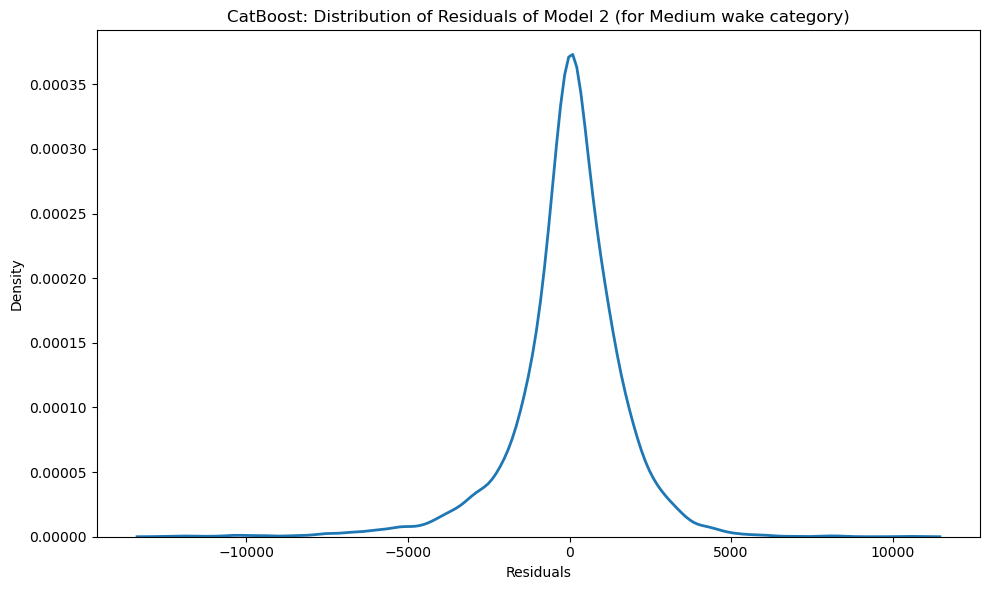

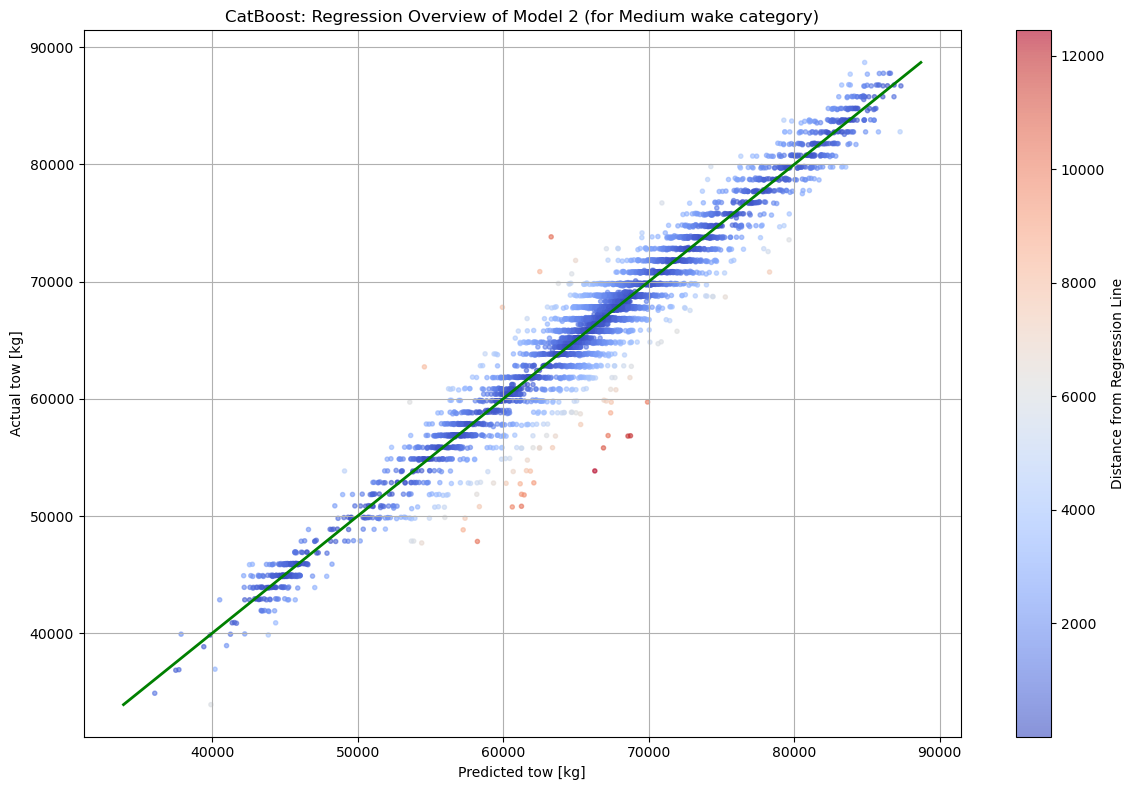

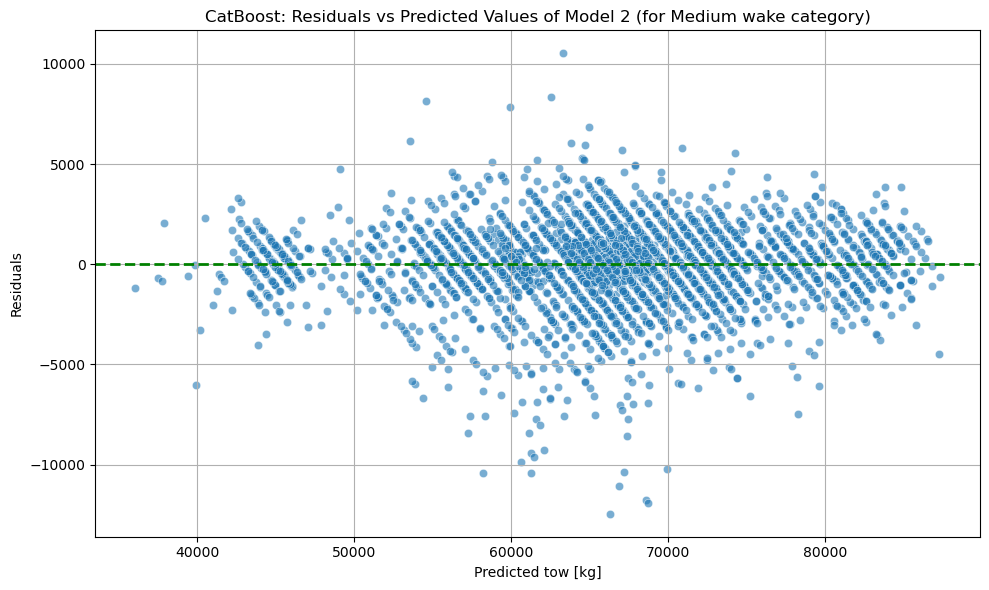

In [25]:
residuals = y_test - y_pred

title1 = "CatBoost: Distribution of Residuals of Model 2 (for Medium wake category)"
title2 = "CatBoost: Regression Overview of Model 2 (for Medium wake category)"
title3 = "CatBoost: Residuals vs Predicted Values of Model 2 (for Medium wake category)"

path1 = "../reports/figures/m2/M_wake/catboost_residuals_distribution.png"
path2 = "../reports/figures/m2/M_wake/catboost_scatter.png"
path3 = "../reports/figures/m2/M_wake/catboost_scatter_residuals.png"

get_model_figs(residuals, y_pred, y_test, title1, title2, title3, path1, path2, path3)

### Model 2 Heavy Wake

In [26]:
X_train, X_test, y_train, y_test, train_pool, test_pool = preprocess_catboost(data_m2_H)

In [27]:
def objective(trial):
    params = {
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1.0, 50.0), 
        'depth': trial.suggest_int('depth', 4, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 30),
        'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations', 1, 15),
    }

    fixed_params = {
        'iterations': 2000, # Max iterations, early stopping will determine actual
        'learning_rate': 0.05, # Fixed learning rate as per original snippet
        'eval_metric': 'RMSE', # Standard string for RMSE
        'random_seed': 42,
        'verbose': False,
        # 'objective': 'RMSE', # In CatBoost, 'loss_function' is preferred, or inferred for Regressor
        'loss_function': 'RMSE',
        'task_type': 'CPU',
        'use_best_model': True, # Crucial for early stopping
        'od_type': 'Iter',      # Early stopping type
        'od_wait': 50,          # Early stopping wait iterations
        'allow_writing_files': False,
    }

    model = CatBoostRegressor(
        **fixed_params,
        **params # Tuned parameters are passed here
    )

    model.fit(train_pool, eval_set=test_pool) 

    best_rmse_on_val = model.get_best_score()['validation']['RMSE'] # Correct for CatBoost
    
    # Store the number of iterations for the best model in this trial
    trial.set_user_attr("best_iteration_count", model.get_best_iteration())
    
    return best_rmse_on_val

In [28]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

print("\n--- Optuna Study Results ---")
print(f"Number of finished trials: {len(study.trials)}")
best_trial = study.best_trial
print(f"Best trial RMSE: {best_trial.value}")
print(f"Best trial params: {best_trial.params}")
optimal_iterations = best_trial.user_attrs.get("best_iteration_count")
print(f"Best trial optimal iterations: {optimal_iterations}")

[I 2025-05-25 21:10:12,278] A new study created in memory with name: no-name-54f70b6d-c2da-4457-91c5-ae1b22d38b6f
[I 2025-05-25 21:10:45,135] Trial 0 finished with value: 5339.699416040855 and parameters: {'reg_lambda': 0.0013927288728908778, 'random_strength': 3.5405350893535203, 'depth': 4, 'min_data_in_leaf': 18, 'leaf_estimation_iterations': 12}. Best is trial 0 with value: 5339.699416040855.
[I 2025-05-25 21:11:21,110] Trial 1 finished with value: 5214.4285530102825 and parameters: {'reg_lambda': 0.47878948049382364, 'random_strength': 48.02713038234964, 'depth': 7, 'min_data_in_leaf': 26, 'leaf_estimation_iterations': 3}. Best is trial 1 with value: 5214.4285530102825.
[I 2025-05-25 21:13:44,512] Trial 2 finished with value: 5512.782343380919 and parameters: {'reg_lambda': 0.0913271775977178, 'random_strength': 43.12593045271358, 'depth': 10, 'min_data_in_leaf': 25, 'leaf_estimation_iterations': 13}. Best is trial 1 with value: 5214.4285530102825.
[I 2025-05-25 21:14:18,264] Tria


--- Optuna Study Results ---
Number of finished trials: 10
Best trial RMSE: 5204.747637602866
Best trial params: {'reg_lambda': 2.0025522776758007, 'random_strength': 7.096582961977249, 'depth': 4, 'min_data_in_leaf': 29, 'leaf_estimation_iterations': 5}
Best trial optimal iterations: 1058


In [29]:
best_hyperparams = best_trial.params.copy()

final_model_params = {
    'iterations': optimal_iterations, # Use the determined optimal number of iterations
    'learning_rate': 0.05,          # As per original fixed param
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'verbose': False,               # Or True if you want to see training output for the final model
    'loss_function': 'RMSE',
    'task_type': 'CPU',
    'allow_writing_files': False,
}
final_model_params.update(best_hyperparams) # Add/overwrite with tuned hyperparams

final_model = CatBoostRegressor(**final_model_params)
final_model.fit(train_pool)

In [30]:
y_pred = final_model.predict(X_test)
r2, mae, rmse, mape =  get_model_metrics(y_pred, X_test, y_test)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error: 3929.58
Root Mean Squared Error: 5205.82
R^2 Score: 0.9664


In [31]:
with open('../models/CatBoost_m2_H.pkl', 'wb') as file:  
    pickle.dump(final_model, file)

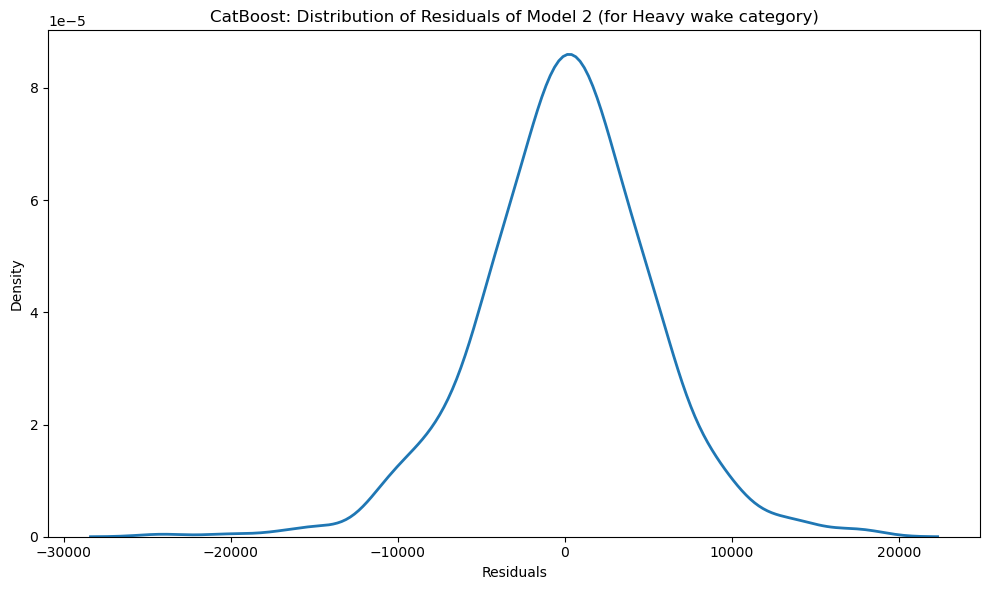

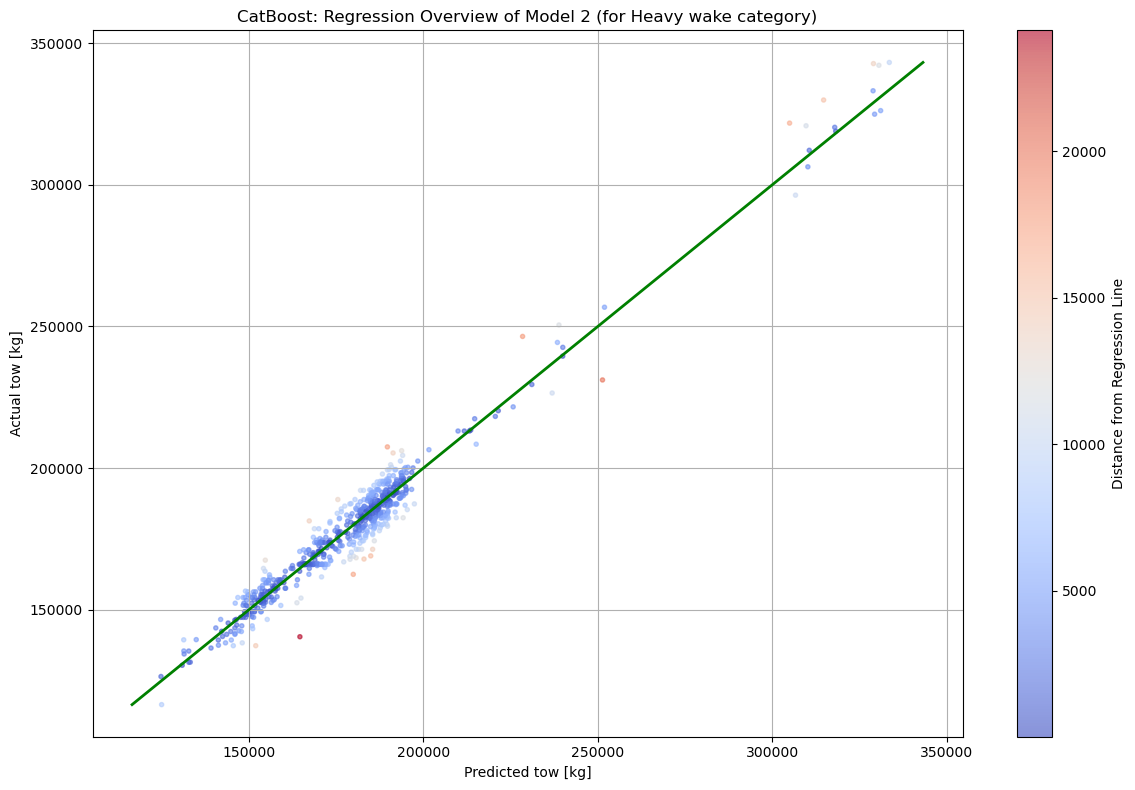

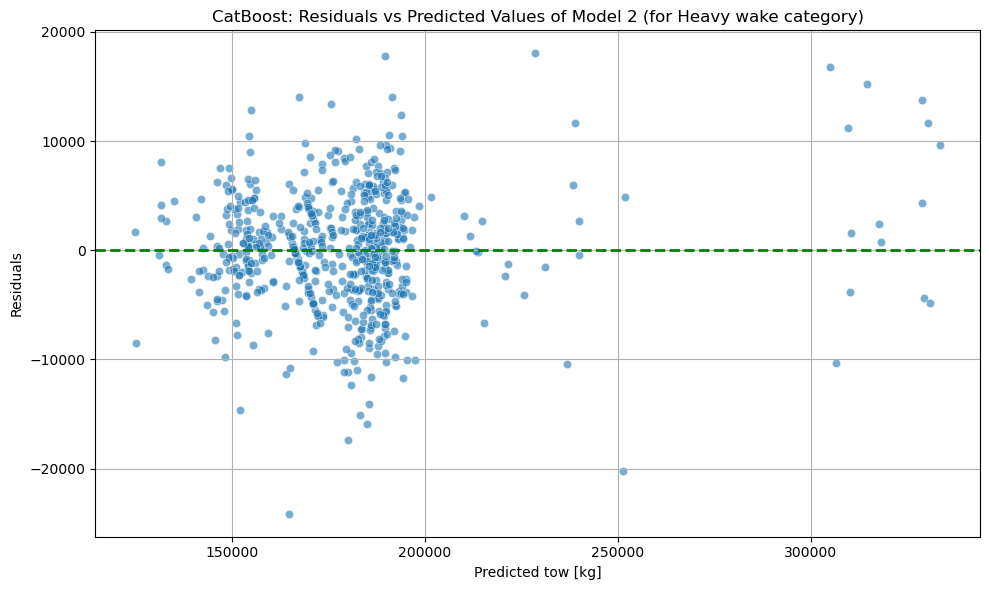

In [32]:
residuals = y_test - y_pred

title1 = "CatBoost: Distribution of Residuals of Model 2 (for Heavy wake category)"
title2 = "CatBoost: Regression Overview of Model 2 (for Heavy wake category)"
title3 = "CatBoost: Residuals vs Predicted Values of Model 2 (for Heavy wake category)"

path1 = "../reports/figures/m2/H_wake/catboost_residuals_distribution.png"
path2 = "../reports/figures/m2/H_wake/catboost_scatter.png"
path3 = "../reports/figures/m2/H_wake/catboost_scatter_residuals.png"

get_model_figs(residuals, y_pred, y_test, title1, title2, title3, path1, path2, path3)

### m1 + m2 (for M wake category)

In [33]:
X_train, X_test, y_train, y_test, train_pool, test_pool = preprocess_catboost(data_M)

In [34]:
def objective(trial):
    params = {
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1.0, 50.0), 
        'depth': trial.suggest_int('depth', 4, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 30),
        'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations', 1, 15),
    }

    fixed_params = {
        'iterations': 2000, # Max iterations, early stopping will determine actual
        'learning_rate': 0.05, # Fixed learning rate as per original snippet
        'eval_metric': 'RMSE', # Standard string for RMSE
        'random_seed': 42,
        'verbose': False,
        # 'objective': 'RMSE', # In CatBoost, 'loss_function' is preferred, or inferred for Regressor
        'loss_function': 'RMSE',
        'task_type': 'CPU',
        'use_best_model': True, # Crucial for early stopping
        'od_type': 'Iter',      # Early stopping type
        'od_wait': 50,          # Early stopping wait iterations
        'allow_writing_files': False,
    }

    model = CatBoostRegressor(
        **fixed_params,
        **params # Tuned parameters are passed here
    )

    model.fit(train_pool, eval_set=test_pool) 

    best_rmse_on_val = model.get_best_score()['validation']['RMSE'] # Correct for CatBoost
    
    # Store the number of iterations for the best model in this trial
    trial.set_user_attr("best_iteration_count", model.get_best_iteration())
    
    return best_rmse_on_val

In [35]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

print("\n--- Optuna Study Results ---")
print(f"Number of finished trials: {len(study.trials)}")
best_trial = study.best_trial
print(f"Best trial RMSE: {best_trial.value}")
print(f"Best trial params: {best_trial.params}")
optimal_iterations = best_trial.user_attrs.get("best_iteration_count")
print(f"Best trial optimal iterations: {optimal_iterations}")

[I 2025-05-25 21:21:33,880] A new study created in memory with name: no-name-58462f51-8538-4c3c-b409-ee8d760094bc
[I 2025-05-25 21:25:42,714] Trial 0 finished with value: 1585.4886160247545 and parameters: {'reg_lambda': 2.2005991038804424, 'random_strength': 42.525283941346395, 'depth': 7, 'min_data_in_leaf': 7, 'leaf_estimation_iterations': 6}. Best is trial 0 with value: 1585.4886160247545.
[I 2025-05-25 21:28:22,146] Trial 1 finished with value: 1652.9688617374154 and parameters: {'reg_lambda': 0.006992102483790975, 'random_strength': 27.143452735582553, 'depth': 5, 'min_data_in_leaf': 22, 'leaf_estimation_iterations': 7}. Best is trial 0 with value: 1585.4886160247545.
[I 2025-05-25 21:31:06,060] Trial 2 finished with value: 1651.3122844946163 and parameters: {'reg_lambda': 0.6622627455042186, 'random_strength': 13.106266136046557, 'depth': 5, 'min_data_in_leaf': 25, 'leaf_estimation_iterations': 7}. Best is trial 0 with value: 1585.4886160247545.
[I 2025-05-25 21:38:48,878] Trial


--- Optuna Study Results ---
Number of finished trials: 10
Best trial RMSE: 1572.027616763004
Best trial params: {'reg_lambda': 0.032508691139752126, 'random_strength': 9.967879624066445, 'depth': 9, 'min_data_in_leaf': 11, 'leaf_estimation_iterations': 6}
Best trial optimal iterations: 1995


In [36]:
best_hyperparams = best_trial.params.copy()

final_model_params = {
    'iterations': optimal_iterations, # Use the determined optimal number of iterations
    'learning_rate': 0.05,          # As per original fixed param
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'verbose': False,               # Or True if you want to see training output for the final model
    'loss_function': 'RMSE',
    'task_type': 'CPU',
    'allow_writing_files': False,
}
final_model_params.update(best_hyperparams) # Add/overwrite with tuned hyperparams

final_model = CatBoostRegressor(**final_model_params)
final_model.fit(train_pool)

In [37]:
y_pred = final_model.predict(X_test)
r2, mae, rmse, mape =  get_model_metrics(y_pred, X_test, y_test)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error: 1050.79
Root Mean Squared Error: 1572.06
R^2 Score: 0.9607


In [38]:
with open('../models/CatBoost_m1+m2_M.pkl', 'wb') as file:  
    pickle.dump(final_model, file)

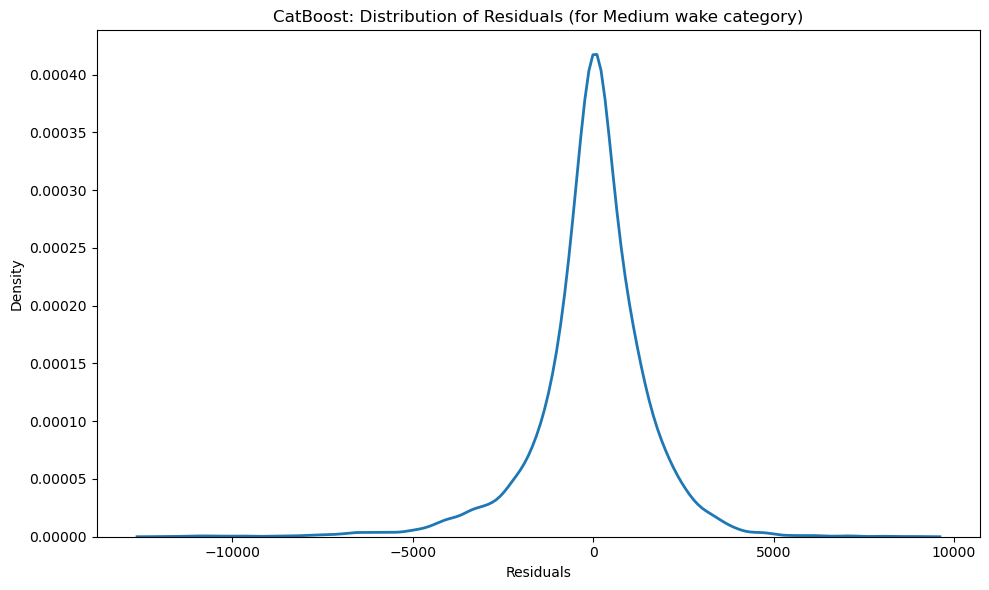

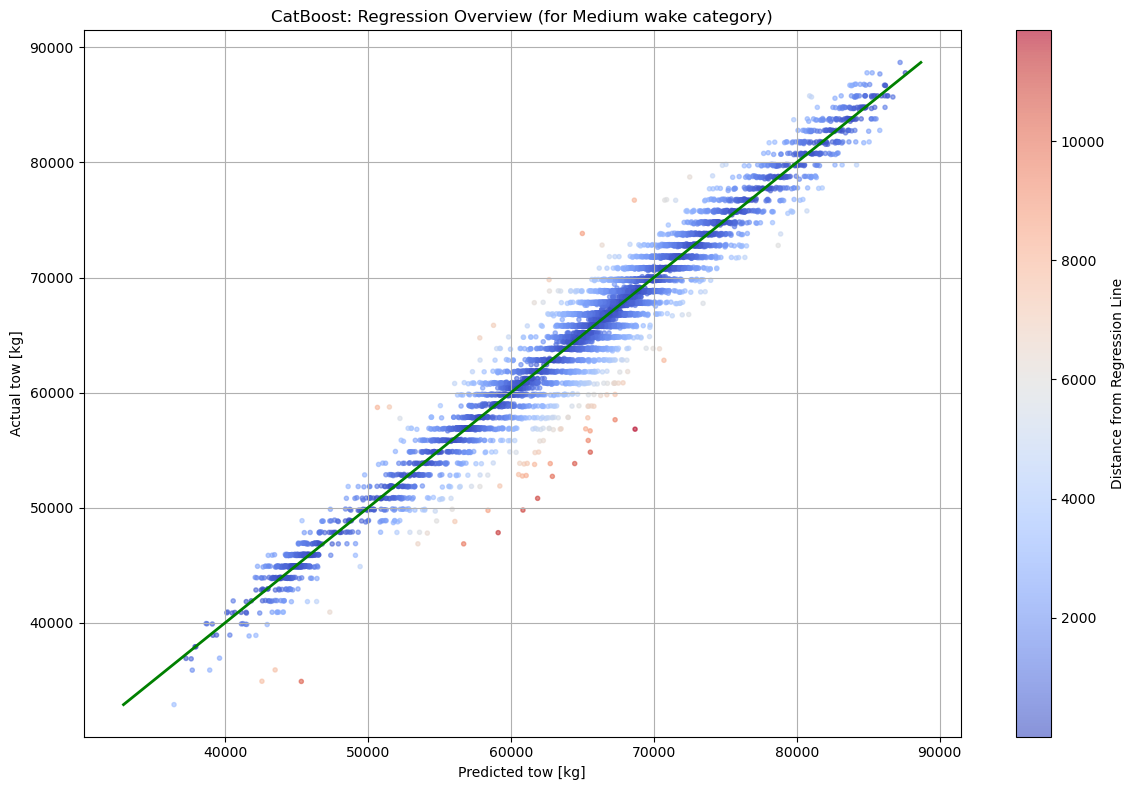

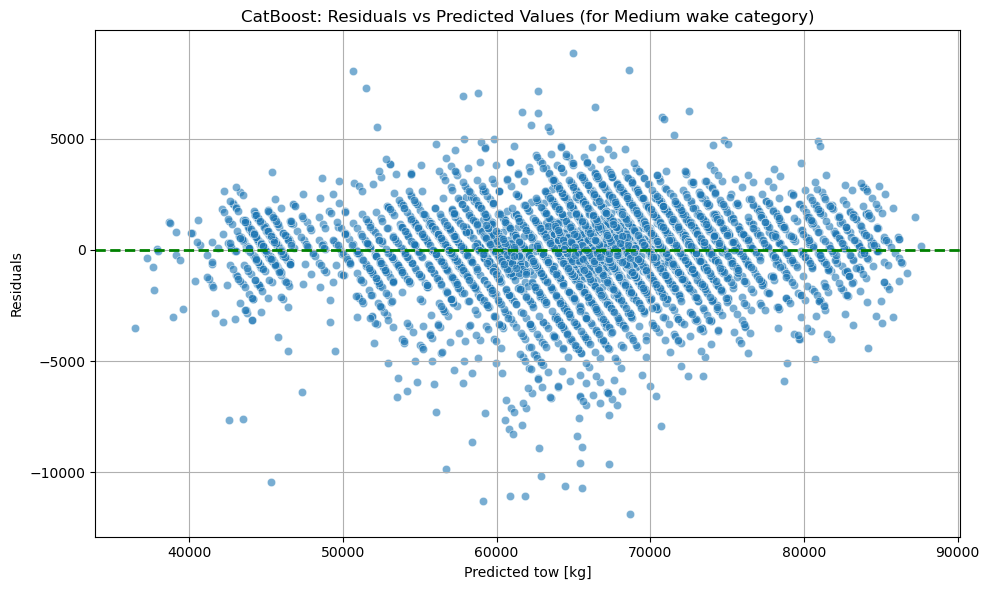

In [39]:
residuals = y_test - y_pred

title1 = "CatBoost: Distribution of Residuals (for Medium wake category)"
title2 = "CatBoost: Regression Overview (for Medium wake category)"
title3 = "CatBoost: Residuals vs Predicted Values (for Medium wake category)"

path1 = "../reports/figures/M/catboost_residuals_distribution.png"
path2 = "../reports/figures/M/catboost_scatter.png"
path3 = "../reports/figures/M/catboost_scatter_residuals.png"

get_model_figs(residuals, y_pred, y_test, title1, title2, title3, path1, path2, path3)

### m1 + m2 (for H wake category)

In [40]:
X_train, X_test, y_train, y_test, train_pool, test_pool = preprocess_catboost(data_H)

In [41]:
def objective(trial):
    params = {
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1.0, 50.0), 
        'depth': trial.suggest_int('depth', 4, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 30),
        'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations', 1, 15),
    }

    fixed_params = {
        'iterations': 2000, # Max iterations, early stopping will determine actual
        'learning_rate': 0.05, # Fixed learning rate as per original snippet
        'eval_metric': 'RMSE', # Standard string for RMSE
        'random_seed': 42,
        'verbose': False,
        # 'objective': 'RMSE', # In CatBoost, 'loss_function' is preferred, or inferred for Regressor
        'loss_function': 'RMSE',
        'task_type': 'CPU',
        'use_best_model': True, # Crucial for early stopping
        'od_type': 'Iter',      # Early stopping type
        'od_wait': 50,          # Early stopping wait iterations
        'allow_writing_files': False,
    }

    model = CatBoostRegressor(
        **fixed_params,
        **params # Tuned parameters are passed here
    )

    model.fit(train_pool, eval_set=test_pool) 

    best_rmse_on_val = model.get_best_score()['validation']['RMSE'] # Correct for CatBoost
    
    # Store the number of iterations for the best model in this trial
    trial.set_user_attr("best_iteration_count", model.get_best_iteration())
    
    return best_rmse_on_val

In [42]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

print("\n--- Optuna Study Results ---")
print(f"Number of finished trials: {len(study.trials)}")
best_trial = study.best_trial
print(f"Best trial RMSE: {best_trial.value}")
print(f"Best trial params: {best_trial.params}")
optimal_iterations = best_trial.user_attrs.get("best_iteration_count")
print(f"Best trial optimal iterations: {optimal_iterations}")

[I 2025-05-25 22:25:28,330] A new study created in memory with name: no-name-a4007bbb-007d-4e9e-a116-bbd0b3250911
[I 2025-05-25 22:28:28,124] Trial 0 finished with value: 5266.083633920688 and parameters: {'reg_lambda': 0.006598416973900985, 'random_strength': 49.78026828150595, 'depth': 10, 'min_data_in_leaf': 13, 'leaf_estimation_iterations': 3}. Best is trial 0 with value: 5266.083633920688.
[I 2025-05-25 22:30:00,901] Trial 1 finished with value: 5186.986350153527 and parameters: {'reg_lambda': 2.8244194783444896, 'random_strength': 42.50576833294346, 'depth': 8, 'min_data_in_leaf': 18, 'leaf_estimation_iterations': 3}. Best is trial 1 with value: 5186.986350153527.
[I 2025-05-25 22:31:01,971] Trial 2 finished with value: 5049.4254473192 and parameters: {'reg_lambda': 0.0018184289914571136, 'random_strength': 24.32158805656794, 'depth': 5, 'min_data_in_leaf': 28, 'leaf_estimation_iterations': 1}. Best is trial 2 with value: 5049.4254473192.
[I 2025-05-25 22:32:00,713] Trial 3 finis


--- Optuna Study Results ---
Number of finished trials: 10
Best trial RMSE: 5003.413282083833
Best trial params: {'reg_lambda': 8.602604617729096, 'random_strength': 16.049872891757158, 'depth': 6, 'min_data_in_leaf': 9, 'leaf_estimation_iterations': 8}
Best trial optimal iterations: 1158


In [43]:
best_hyperparams = best_trial.params.copy()

final_model_params = {
    'iterations': optimal_iterations, # Use the determined optimal number of iterations
    'learning_rate': 0.05,          # As per original fixed param
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'verbose': False,               # Or True if you want to see training output for the final model
    'loss_function': 'RMSE',
    'task_type': 'CPU',
    'allow_writing_files': False,
}
final_model_params.update(best_hyperparams) # Add/overwrite with tuned hyperparams

final_model = CatBoostRegressor(**final_model_params)
final_model.fit(train_pool)

In [44]:
y_pred = final_model.predict(X_test)
r2, mae, rmse, mape =  get_model_metrics(y_pred, X_test, y_test)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error: 3770.15
Root Mean Squared Error: 5003.87
R^2 Score: 0.9531


In [45]:
with open('../models/CatBoost_m1+m2_H.pkl', 'wb') as file:  
    pickle.dump(final_model, file)

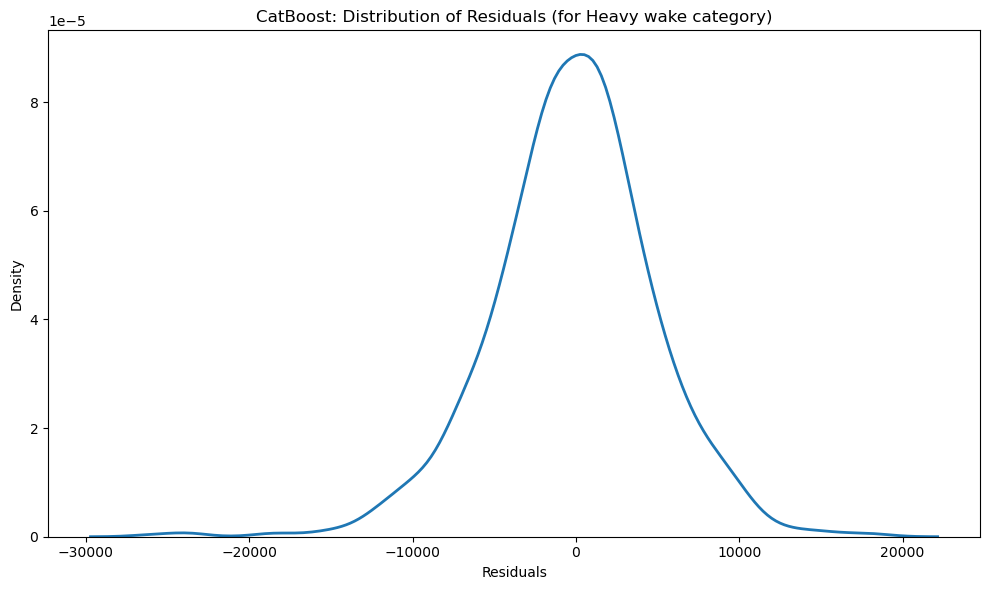

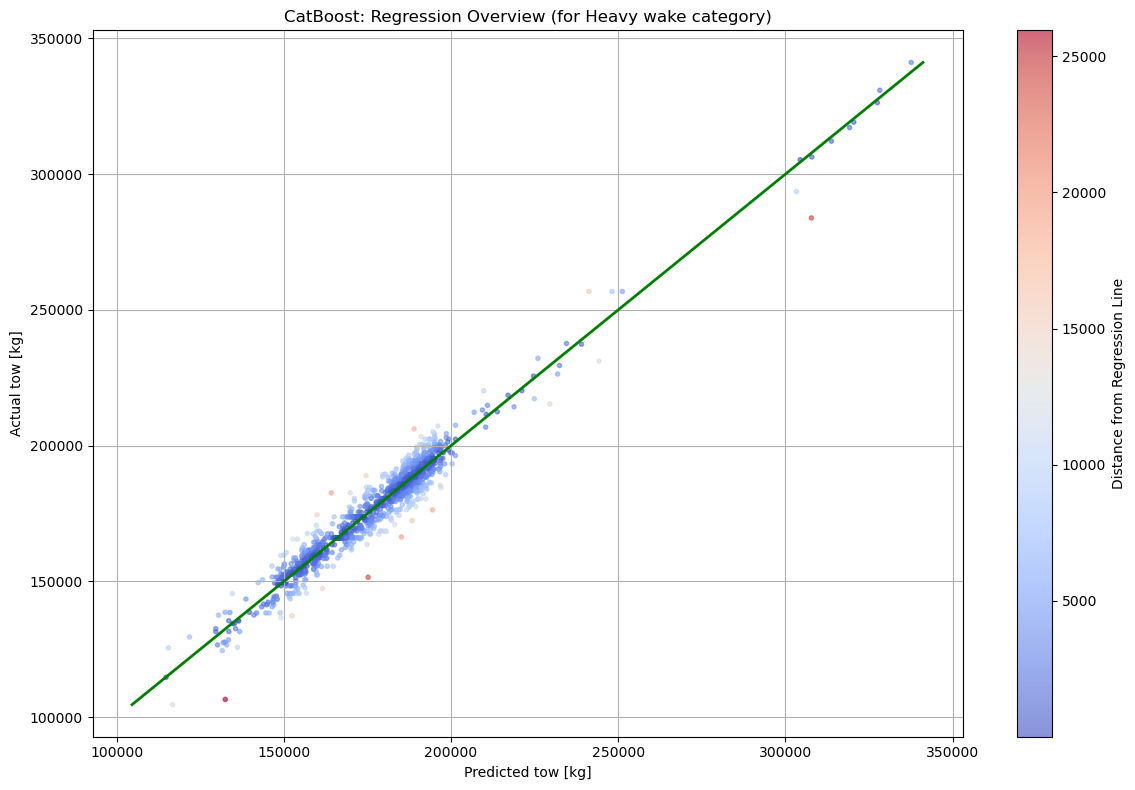

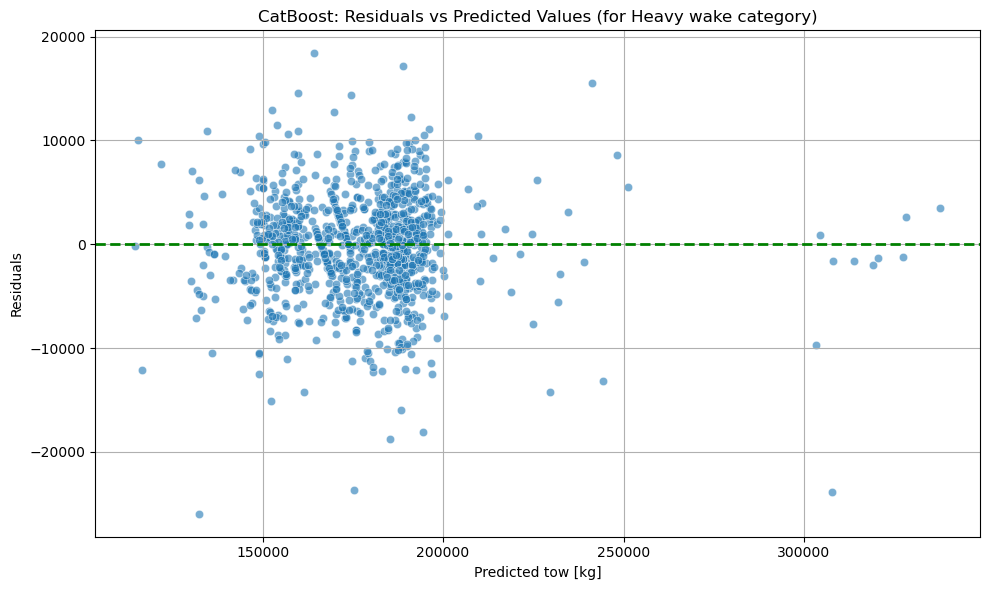

In [46]:
residuals = y_test - y_pred

title1 = "CatBoost: Distribution of Residuals (for Heavy wake category)"
title2 = "CatBoost: Regression Overview (for Heavy wake category)"
title3 = "CatBoost: Residuals vs Predicted Values (for Heavy wake category)"

path1 = "../reports/figures/H/catboost_residuals_distribution.png"
path2 = "../reports/figures/H/catboost_scatter.png"
path3 = "../reports/figures/H/catboost_scatter_residuals.png"

get_model_figs(residuals, y_pred, y_test, title1, title2, title3, path1, path2, path3)

In [35]:
# feature_importances = model.get_feature_importance(train_pool)
# feature_names = X_train.columns
# for score, name in sorted(zip(feature_importances, feature_names), reverse=True):
#     print('{}: {}'.format(name, score))

In [36]:
# feature_im_df = pd.DataFrame({
#     "feature": X.columns,
#     "importance": feature_importances
# })

# feature_im_df = feature_im_df.sort_values(by="importance", ascending=False)


# plt.figure(figsize=(10, 6))
# ax = sns.barplot(data = feature_im_df[:20], x='importance', y='feature')

# for p in ax.patches:
#     width = p.get_width()
#     ax.text(width + 0.005,                # x-coordinate (slightly offset)
#             p.get_y() + p.get_height() / 2,  # y-coordinate (center of bar)
#             f'{width:.3f}',               # label text
#             va='center')
# max_width = feature_im_df['importance'].head(20).max()
# ax.set_xlim(0, max_width + 1.2)  # Agrega margen derecho

# plt.title("CatBoost feature importance")
# plt.xlabel("Importance")
# plt.ylabel("feature")
# plt.tight_layout()
# plt.show()